# Eulerverfahren

Das **explizite Eulerverfahren** zur Lösung eines AWP
$$
    y' = f(x, y), \qquad y(x_0) = y_0
$$

ist gegeben durch

$$
    y_{k+1} = y_k + h \cdot f(x_k, y_k)
$$

Das **implizite Eulerverfahren** ist

$$
    y_{k+1} = y_k + h \cdot f(x_{k+1}, y_{k+1})
$$

Das implizite Verfahren stellt eine Gleichung für $y_{k+1}$ dar, die in jedem Schritt gelöst werden muss. 


## Aufgabe 1: explizites Eulerverfahren
  
Implementieren Sie das explizite Eulerverfahren und testen Sie das Verfahren an dem AWP

$$
y' = - 4 \cdot y, \qquad y(0) = 2, \qquad x \in [0, 2]
$$

Bestimmen Sie den Fehler 

$$
    e = |y_n - y(2)|
$$

der numerischen Lösung im Vergleich zum korrekten Wert $y(2)$ für verschiedene Schrittweiten $h$, beispielsweise

$$
    h \in \left\{10^{-1}, 10^{-2}, 10^{-3}, 10^{-4}, 10^{-5} \right\}
$$

Erstellen Sie einen logarithmischen plot des Fehlers $e$ in Abhängigkeit der Schrittweite. Es sollte herauskommen, dass der Fehler im wesentlichen proportional zu $h$ ist.

**Bemerkungen:**   
* Achten Sie darauf, dass Sie die Endstelle $x_n = 2$ für jede Schrittweite genau treffen.
* Die Funktion $f(x, y)$ ist hier von $x$ unabhängig. Es empfiehlt sich, $f$ trotzdem als Funktion von zwei Variablen $x, y$ zu definieren, weil das ja nicht immer so ist.
* Definieren Sie eine Funktion für das Eulerverfahren, die später wiederverwendbar ist. Der untenstehende Code ist ein Vorschlag für die Schnittstelle der Funktion

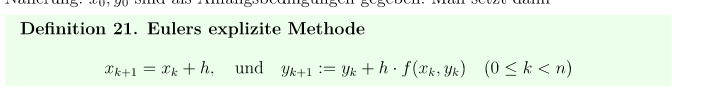

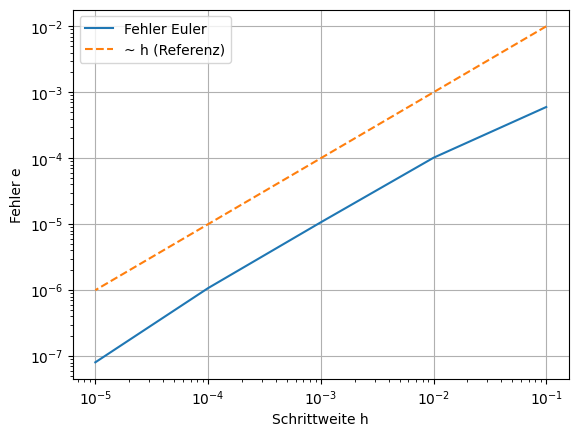

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# explizites Eulerverfahren für y' = f(x, y), y(x0) = y0, Integration bis xn mit fester Schrittweite h
def eulerExplizit(f, x0, y0, xn, h):
# initialisieren, der startpunkt aus den übergebenen startbedinung:

# TYP LISTE!
    x = [x0]
    y = [y0]

    n = int((xn - x0) / h) ## anzahl schritte finden, ende minus anfang durch weite

    for i in range (n):
        x_alt = x[-1] ## letzer wert
        y_alt = y[-1] ## letzer wert
        x_neu = x_alt + h ## neuer x wert
        y_neu = y_alt + h * f(x_alt, y_alt) ## neuer y wert
        ##Werte an die Listen anhängen  ## APEND IST LISTE ANHäNGEN!
        x.append(x_neu)
        y.append(y_neu)
    return np.array(x), np.array(y) ## ergebnis zurückgeben

    
f = lambda x, y: - 4 * y # praktisch: einheitliche Schnittstelle für f(x, y), auch wenn x hier gar nicht vorkommt

x0 = 0
y0 = 2
xn = 2

## GEGEBEN, ABER & WErte hs = np.logspace(-1, -5, 6) # noch viel kleinere Schrittweiten h ergeben evtl. lange Rechenzeiten...
# SO IST ES EXAKT WIE IM BILD VERLANGT:
hs = np.logspace(-1, -5, 5)

## exakte lösung:
#erklärung gemeni da an2 lange her ist:
# 1. Die DGL y' = -4y ist eine lineare homogene DGL 1. Ordnung (Typ: y' = k*y).
# 2. Der allgemeine Lösungsansatz für diesen Typ ist die Exponentialfunktion: y(x) = C * exp(k * x).
# 3. Hier ist k = -4, also: y(x) = C * exp(-4 * x).
# 4. Bestimmung von C durch den Anfangswert y(0) = 2:
#    2 = C * exp(-4 * 0)  =>  2 = C * 1  =>  C = 2.
yexact = lambda x: 2 * np.exp(-4 * x)  ## regeln aus analysis 2: 


errE = [] #Liste zur Speicherung der Fehler für das Eulerverfahren

for h in hs:  # 6 mal euler aufrufen, siehe definition von hs 
    xe, ye = eulerExplizit(f, x0, y0, xn, h) 
    err = abs(ye[-1] - yexact(2))  #exakte Lösung der DGL an der Stelle x=2: y(2) = 2 * e^(-4*2) = 2 * e^(-8)

    errE.append(err)

errE = np.array(errE)

# Plot
plt.figure()
plt.loglog(hs, errE, label='Fehler Euler')
plt.loglog(hs, 1e-1 * hs, '--', label='~ h (Referenz)')
plt.xlabel('Schrittweite h')
plt.ylabel('Fehler e')
plt.legend()
plt.grid(True)
plt.show()


## Aufgabe 2: implizites Eulerverfahren

Implementieren Sie das **implizite Eulerverfahren**. Verwenden Sie in jedem Schritt ein (skalares) Newtonverfahren zur Lösung der Gleichung

$$
    g(s) :=  y_{k} + h \cdot f(x_{k} + h, {\color{red} s}) - {\color{red} s} \stackrel!= 0, \qquad y_{k+1} = s
$$

* Testen Sie das Verfahren mit demselben AWP wie für das explizite Verfahren
* Erstellen Sie einen logarithmischen plot des Fehlers $e$ in Abhängigkeit der Schrittweite wie für das explizite Verfahren. Auch hier sollte $e$ proportional zu $h$ herauskommen.

**Bemerkungen** 
* Die Bemerkungen zu Aufgabe 1 gelten immer noch
* bei sehr kurzen Schrittweiten dauert die Berechnung etwas. Verfahren, die genauere Ergebnisse mit grösseren Schrittweiten liefern sehen wir nächste Woche.

formel
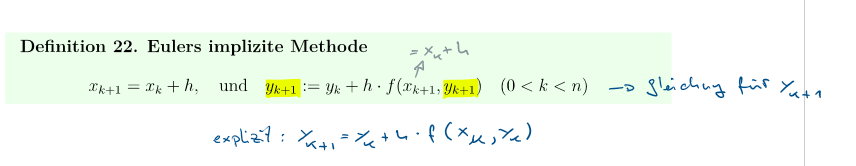
dummy code:
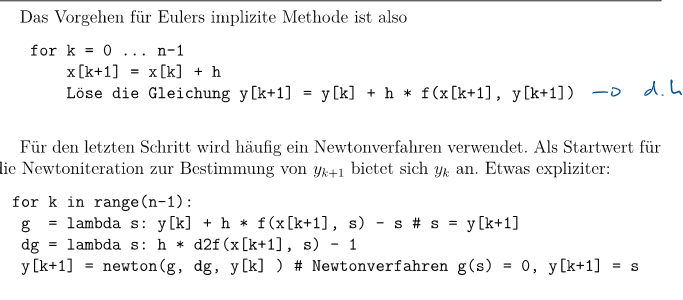

In [12]:
# Newtonverfahren, für skalare Gleichungen (also der Newton aus AN1...)
def newton(f, df, x, maxit = 100):
<<snipp>>

# implizites Eulerverfahren für y' = f(x, y), y(x0) = y0, Integration bis xn mit fester Schrittweite h
# d2f = partielle Ableitung von f nach der zweiten Variablen (y), für das Newtonverfahren
def eulerImplizit(f, df, x0, y0, xn, h):
<<snipp>>

# Ableitung von f nach y (für Newtonverfahren)
df = lambda x, y: <<snipp>>

h = 0.1
xi, yi = eulerImplizit(f, df, x0, y0, xn, h)

# plt.plot(xe, ye)
plt.plot(xi, yi)
plt.plot(xe, yexact(xe))

errI = []
for h in hs:
    print("h = ", h)
    xh, yh = eulerImplizit(f, df, x0, y0, xn, h)
    errI.append( yexact(xh[-1]) - yh[-1] )

plt.figure()
plt.loglog(hs, np.abs(errI), label = "implizit")
plt.loglog(hs, np.abs(errE), label = "explizit")
plt.loglog(hs, 1e-2*hs, '--', label = "h")
plt.legend()

IndentationError: expected an indented block after function definition on line 2 (792753346.py, line 3)

## Aufgabe 3
Verwenden Sie das explizite und das implizite Eulerverfahren, um das AWP

$$
    y' + \frac{x^2}{y} = 0, \qquad y(0) = -4, \qquad x \in [0, 2] 
$$

zu lösen. 
* Vergleichen Sie mit der exakten Lösung 

$$
    y(2) = - \frac{4}{3} \, \sqrt{6}
$$

* Visualisieren Sie die numerische Lösung im Richtungsfeld der Differentialgleichung. Für die Visualisierung des Richtungsfeldes gibt es den Befehl *quiver*.


In [ ]:
f = lambda x, y: - x**2 / y

xq = np.linspace(0, 2, 10)        # x-Achse für Vektorfeld
yq = np.linspace(-4.5, -3, 10)    # y-Achse für Vektorfeld

X, Y = np.meshgrid(xq, yq)        # Raster aus den Achsen erzeugen

u = lambda x, y: np.ones_like(x) # x' = 1
v = lambda x, y: f(x, y)         # y' = f(x, y)

# die Option angles = "xy" sorgt dafür, dass die Steigung an die Skalierung der Achsen angepasst wird
plt.quiver(X, Y, u(X, Y), v(X, Y), angles = "xy", color = [.7,.7,.7])

In [ ]:
<<snipp>>